# Set up
**Import libraries**

In [1]:
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from knmy import knmy
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
)
from sklearn.preprocessing import StandardScaler

**Load and merge datasets**

In [2]:
df = pd.read_csv("../data/bunny.csv", dtype={'Oryctolagus cuniculus': str})
habitat = pd.read_csv("../data/habitats.csv")

# Merge habitats with bunny data with only matching decimalLatitude and decimalLongitude values
df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

In [3]:
from scipy.spatial.distance import cdist
# Stations lookup
stations_data = {
    'station': [260, 240, 280, 270, 350, 380, 290, 310, 370, 235, 275, 344, 257],
    'lat': [52.101, 52.318, 53.125, 53.202, 51.449, 50.906, 52.933, 51.501, 52.933, 52.928, 52.056, 51.962, 52.506],
    'lon': [5.177, 4.790, 6.585, 5.752, 3.596, 5.762, 4.788, 5.707, 5.444, 4.781, 5.872, 4.447, 4.604],
    'name': ['De Bilt', 'Schiphol', 'Eelde', 'Leeuwarden', 'Vlissingen', 'Maastricht', 
             'Twente', 'Eindhoven', 'Lelystad', 'De Kooy', 'Deelen', 'Rotterdam', 'Wijk aan Zee']
}
stations_df = pd.DataFrame(stations_data)

# Ensure datetime
df["eventDate"] = pd.to_datetime(df["eventDate"])

# Unique locations + nearest station
unique_locs = df[['decimalLatitude', 'decimalLongitude']].drop_duplicates().reset_index(drop=True)

loc_coords = unique_locs[['decimalLatitude', 'decimalLongitude']].values
station_coords = stations_df[['lat', 'lon']].values

distances = cdist(loc_coords, station_coords, metric='euclidean')
nearest_idx = np.argmin(distances, axis=1)

unique_locs['nearest_station'] = stations_df['station'].iloc[nearest_idx].values
unique_locs['station_name'] = stations_df['name'].iloc[nearest_idx].values


# Merge station info back
df = df.merge(unique_locs, 
              on=['decimalLatitude', 'decimalLongitude'], 
              how='left')

# Check if merge worked
print("Columns after station merge:", [col for col in df.columns if 'station' in col.lower() or 'nearest' in col.lower()])

# Download weather
start_date = df["eventDate"].min().strftime("%Y%m%d")
end_date   = df["eventDate"].max().strftime("%Y%m%d")

weather_list = []

for station_id in sorted(unique_locs['nearest_station'].unique()):
    print(f"🌧️  Downloading data for station {station_id}...")
    try:
        weather_raw = knmy.get_knmi_data(
            type="daily",
            stations=[int(station_id)],
            start=start_date,
            end=end_date
        )
        
        weather_df = pd.read_csv(StringIO(weather_raw), comment='#', skipinitialspace=True, header=None)
        
        weather_df = weather_df.rename(columns={0: "STN", 1: "YYYYMMDD", 11: "TG", 18: "SQ", 22: "RH"})
        
        weather_df["YYYYMMDD"] = weather_df["YYYYMMDD"].astype(str)
        weather_df["eventDate"] = pd.to_datetime(weather_df["YYYYMMDD"], format="%Y%m%d").dt.normalize()
        
        weather_df["temp_mean"] = pd.to_numeric(weather_df["TG"], errors="coerce") / 10
        weather_df["precip_sum"] = pd.to_numeric(weather_df["RH"], errors="coerce") / 10
        weather_df["sunshine_duration"] = pd.to_numeric(weather_df["SQ"], errors="coerce") / 10
        weather_df["station"] = station_id
        
        weather_list.append(weather_df[['eventDate', 'station', 'temp_mean', 'precip_sum', 'sunshine_duration']])
        
    except Exception as e:
        print(f"⚠️ Error for station {station_id}: {e}")

# Final merge
if weather_list:
    all_weather = pd.concat(weather_list, ignore_index=True)
    
    df = df.merge(
        all_weather, 
        left_on=['eventDate', 'nearest_station'], 
        right_on=['eventDate', 'station'], 
        how='left'
    )
    
    df = df.drop(columns=['station'], errors='ignore')   # remove duplicate
    
    print("🎉 Success! Weather merged with location-specific data.")
    print(df[['temp_mean', 'precip_sum', 'sunshine_duration']].describe())
    print("\nSample rows:")
    print(df[['eventDate', 'nearest_station', 'station_name', 'temp_mean']].head())
else:
    print("❌ No weather data was downloaded.")

Columns after station merge: ['nearest_station', 'station_name']
🌧️  Downloading data for station 235...
🌧️  Downloading data for station 240...
🌧️  Downloading data for station 257...
🌧️  Downloading data for station 260...
🌧️  Downloading data for station 270...
🌧️  Downloading data for station 275...
🌧️  Downloading data for station 280...
🌧️  Downloading data for station 290...
🌧️  Downloading data for station 310...
🌧️  Downloading data for station 344...
🌧️  Downloading data for station 350...
🌧️  Downloading data for station 370...
🌧️  Downloading data for station 380...
🎉 Success! Weather merged with location-specific data.
          temp_mean    precip_sum  sunshine_duration
count  1.255841e+07  1.255841e+07       1.255824e+07
mean   1.087049e+01  2.255315e+00       5.071856e+00
std    6.225544e+00  4.692560e+00       4.236428e+00
min   -1.380000e+01 -1.000000e-01      -1.000000e-01
25%    6.400000e+00  0.000000e+00       1.200000e+00
50%    1.080000e+01  1.000000e-01       4.

**Feature enginering**

Because of in the CRISP-DM cycle we went back and forth between data understanding and data preparation and therefore need need the data preparation part feature enigerening before data understanding we are placing it here

In [4]:
df["spotted"] = (
    pd.to_numeric(df["Oryctolagus cuniculus"], errors="coerce")
    .fillna(0)
    .gt(0)
    .astype(int)
)

df = df.sort_values(["decimalLatitude", "decimalLongitude", "eventDate"])

# Create the future spotted flag
df["is_spotted"] = (
    df.groupby(["decimalLatitude", "decimalLongitude"])["spotted"]
      .transform(lambda x: x[::-1].rolling(window=30, min_periods=1).max()[::-1].shift(-1).fillna(0).astype(int))
)

# to find time patterns
df["day_of_year"] = df["eventDate"].dt.dayofyear
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

---

# 1. Business Understanding

**Business Objective** 

* The objective of this project is to develop a predictive model for observations of Oryctolagus cuniculus using environmental and temporal factors such as habitat type, seasonality, temperature, precipitation, and geographic location.
The model aims to predict where and when rabbit observations are most likely to occur, helping improve biodiversity monitoring, ecological research, and wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
    * Achieves at least 75% prediction accuracy on unseen observation data
    * Correctly identifies seasonal and habitat-related patterns in rabbit observations
    * Maintains stable performance across different geographic regions and weather conditions

**Data Mining Goals**

* Develop a classification model that predicts the likelihood of observing Oryctolagus cuniculus using environmental variables such as habitat type, seasonality, temperature, precipitation, and geographic location.

**Data Mining Success Criteria**

* Our model should achieve at least:
75% accuracy in predicting observations of Oryctolagus cuniculus
70% precision when identifying locations and time periods with rabbit observations
75% recall in detecting actual rabbit observation occurrences based on habitat, seasonal, and weather-related variables
The model should also maintain stable predictive performance across different regions and seasons.

---


# 2.1 Data understanding
**Data exploration**

In [5]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,...,nearest_station,station_name,temp_mean,precip_sum,sunshine_duration,spotted,is_spotted,day_of_year,day_sin,day_cos
12558769,3.5,52.8,2026-01-14,10.0,1011,3,NaN,NaN,NaN,NaN,...,380,Maastricht,8.5,4.6,0.0,1,0,14,0.238673,0.971100
12558767,3.5,52.9,2026-01-12,100.0,1011,unknown,NaN,NaN,NaN,NaN,...,380,Maastricht,5.7,6.1,0.0,0,0,12,0.205104,0.978740
12558765,3.5,53.0,2026-01-10,10.0,1011,5,NaN,NaN,NaN,NaN,...,380,Maastricht,-2.7,2.0,0.0,1,0,10,0.171293,0.985220
12558761,3.5,53.1,2026-01-06,99999.0,1011,8,NaN,NaN,NaN,NaN,...,380,Maastricht,-1.5,0.1,1.5,1,0,6,0.103102,0.994671
12558760,3.5,53.2,2026-01-05,40.0,1011,-1,NaN,NaN,NaN,NaN,...,380,Maastricht,-2.3,2.0,0.2,0,0,5,0.085965,0.996298


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558786 entries, 12558769 to 12558755
Data columns (total 25 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Oryctolagus cuniculus      str           
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  nearest_station            int64         
 16  station_name               str           
 

In [7]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,...,wetland,nearest_station,temp_mean,precip_sum,sunshine_duration,spotted,is_spotted,day_of_year,day_sin,day_cos
count,1.255879e+07,1.255879e+07,12558786,1.255878e+07,1.255879e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,...,1.255876e+07,1.255879e+07,1.255841e+07,1.255841e+07,1.255824e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,2017-12-31 12:10:06.165594,8.136004e+00,2.212651e-01,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,1.501486e+00,...,2.249716e-01,2.988666e+02,1.087049e+01,2.255315e+00,5.071856e+00,5.475927e-03,9.970088e-02,1.831249e+02,1.240474e-05,6.866384e-04
min,3.500000e+00,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.350000e+02,-1.380000e+01,-1.000000e-01,-1.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,-9.999907e-01,-9.999630e-01
25%,5.170000e+01,4.900000e+00,2014-01-01 00:00:00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,7.249000e-01,...,0.000000e+00,2.750000e+02,6.400000e+00,0.000000e+00,1.200000e+00,0.000000e+00,0.000000e+00,9.200000e+01,-7.055836e-01,-7.086267e-01
50%,5.220000e+01,5.650000e+00,2018-01-01 00:00:00,1.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,1.199800e+00,...,1.820000e-02,2.800000e+02,1.080000e+01,1.000000e-01,4.400000e+00,0.000000e+00,0.000000e+00,1.830000e+02,6.432491e-16,4.303538e-03
75%,5.280000e+01,6.200000e+00,2022-01-01 00:00:00,6.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,2.006500e+00,...,1.417000e-01,3.440000e+02,1.580000e+01,2.500000e+00,8.200000e+00,0.000000e+00,0.000000e+00,2.740000e+02,7.055836e-01,7.025275e-01
max,5.350000e+01,5.340000e+01,2026-01-30 00:00:00,1.000400e+05,1.637000e+03,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,1.039830e+01,...,1.422410e+01,3.800000e+02,3.120000e+01,1.316000e+02,1.570000e+01,1.000000e+00,1.000000e+00,3.660000e+02,9.999907e-01,1.000000e+00
std,6.647267e-01,8.779710e-01,NaN,6.264853e+01,2.511784e+00,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,1.167872e+00,...,7.063523e-01,3.965583e+01,6.225544e+00,4.692560e+00,4.236428e+00,7.379663e-02,2.996008e-01,1.054388e+02,7.068642e-01,7.073490e-01


**Check data distribution**

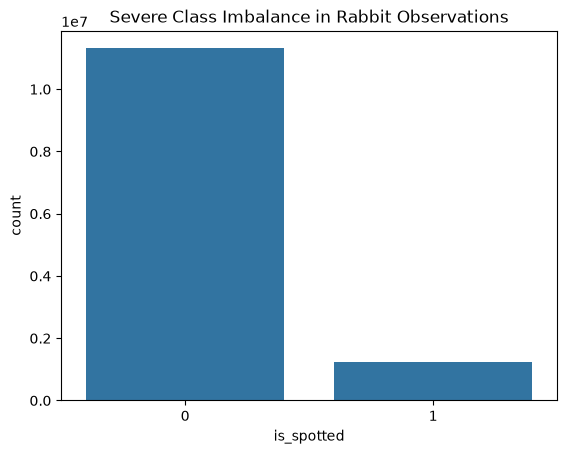

In [8]:
sns.countplot(data=df, x='is_spotted')
plt.title('Severe Class Imbalance in Rabbit Observations')
plt.show()

In [9]:
habitat_summary = df['main_habitat'].value_counts().reset_index()
habitat_summary.columns = ['Habitat', 'Count']
habitat_summary['Percentage'] = (habitat_summary['Count'] / habitat_summary['Count'].sum()) * 100

print(habitat_summary)

        Habitat    Count  Percentage
0  agricultural  9233520   73.522569
1         coast  1098672    8.748255
2         built   958416    7.631456
3        forest   631152    5.025593
4         water   543492    4.327594
5         other    40908    0.325733
6  sand/heather    29220    0.232666
7       wetland    23376    0.186133


Generating clean plots for 12 variables...



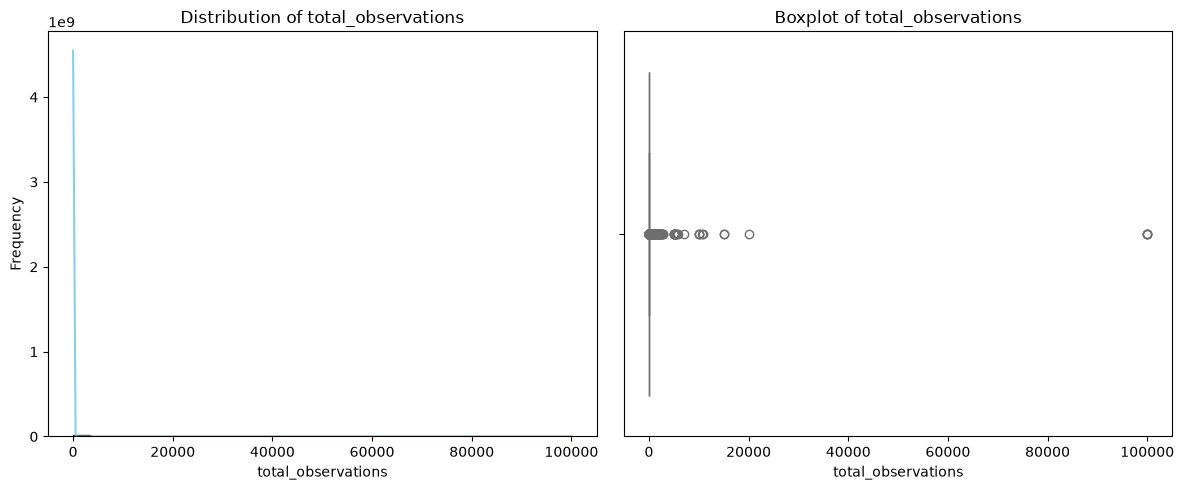


--- total_observations ---
Mean:     8.136
Median:   1.000
Std:      62.649
Min:      0.000
Max:      100040.000
Skewness: 1303.379
Missing:  3 rows
--------------------------------------------------


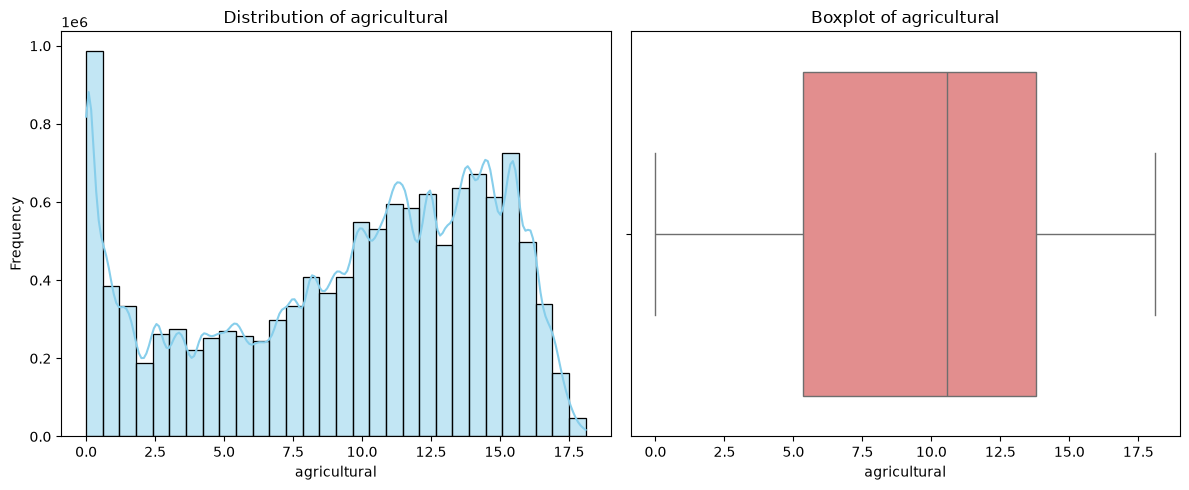


--- agricultural ---
Mean:     9.452
Median:   10.568
Std:      5.148
Min:      0.000
Max:      18.105
Skewness: -0.446
Missing:  30 rows
--------------------------------------------------


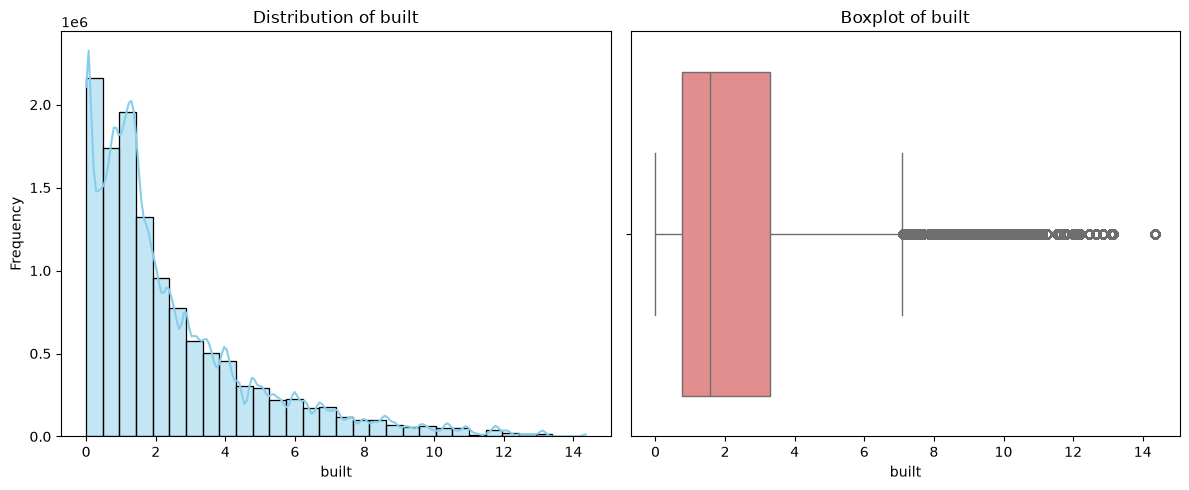


--- built ---
Mean:     2.405
Median:   1.560
Std:      2.420
Min:      0.000
Max:      14.354
Skewness: 1.710
Missing:  30 rows
--------------------------------------------------


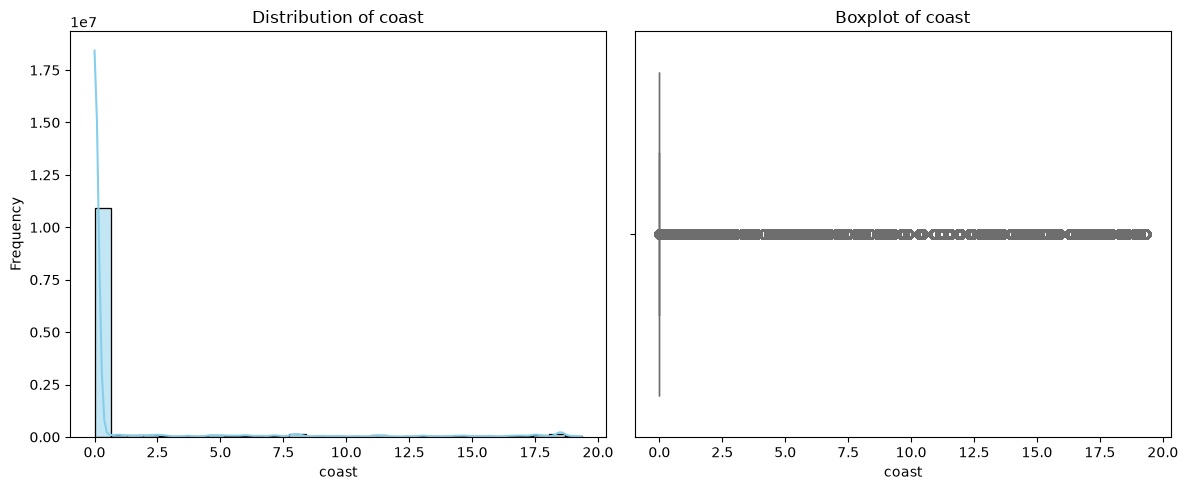


--- coast ---
Mean:     1.303
Median:   0.000
Std:      3.970
Min:      0.000
Max:      19.349
Skewness: 3.237
Missing:  30 rows
--------------------------------------------------


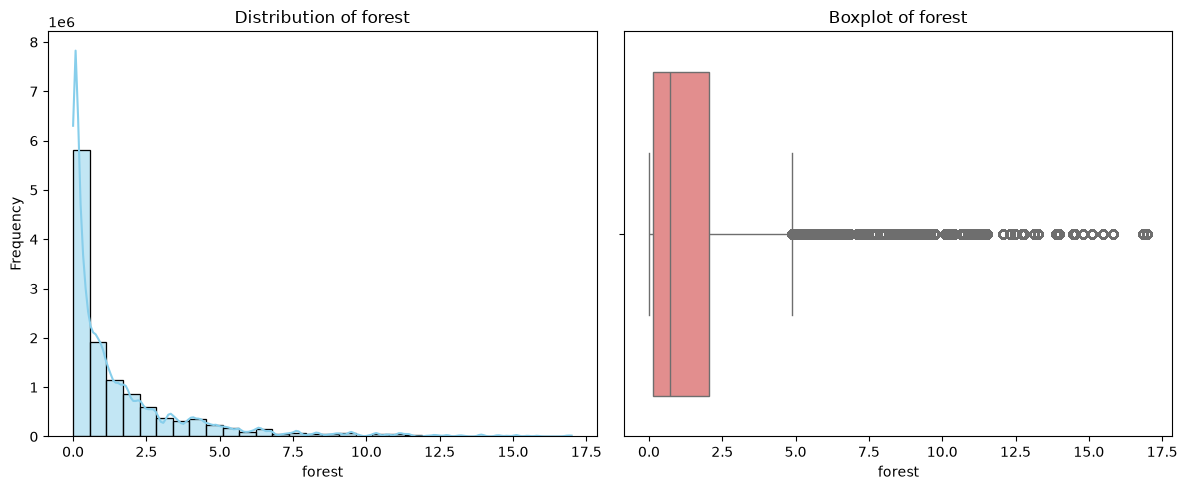


--- forest ---
Mean:     1.621
Median:   0.709
Std:      2.386
Min:      0.000
Max:      16.998
Skewness: 2.705
Missing:  30 rows
--------------------------------------------------


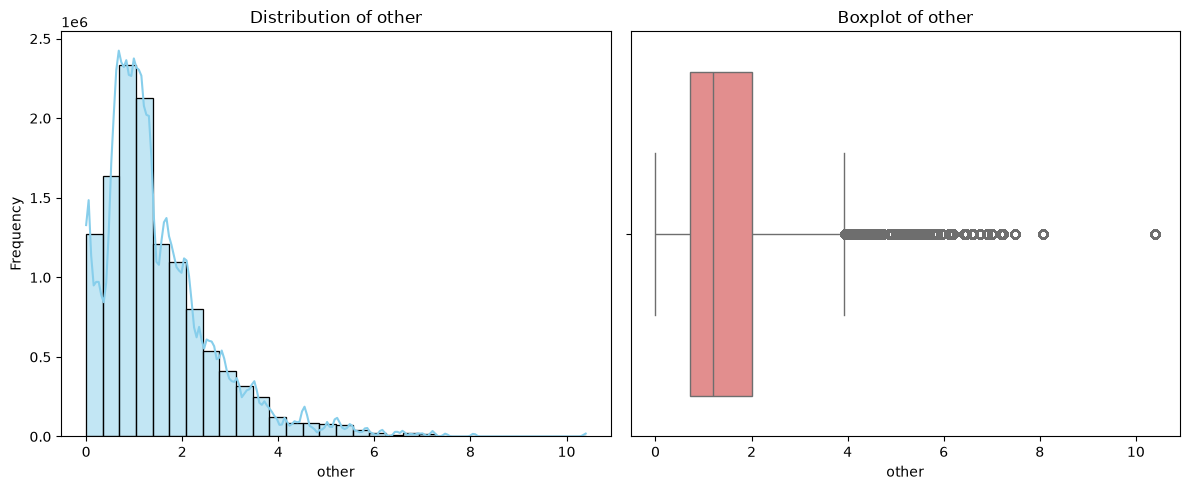


--- other ---
Mean:     1.501
Median:   1.200
Std:      1.168
Min:      0.000
Max:      10.398
Skewness: 1.754
Missing:  30 rows
--------------------------------------------------


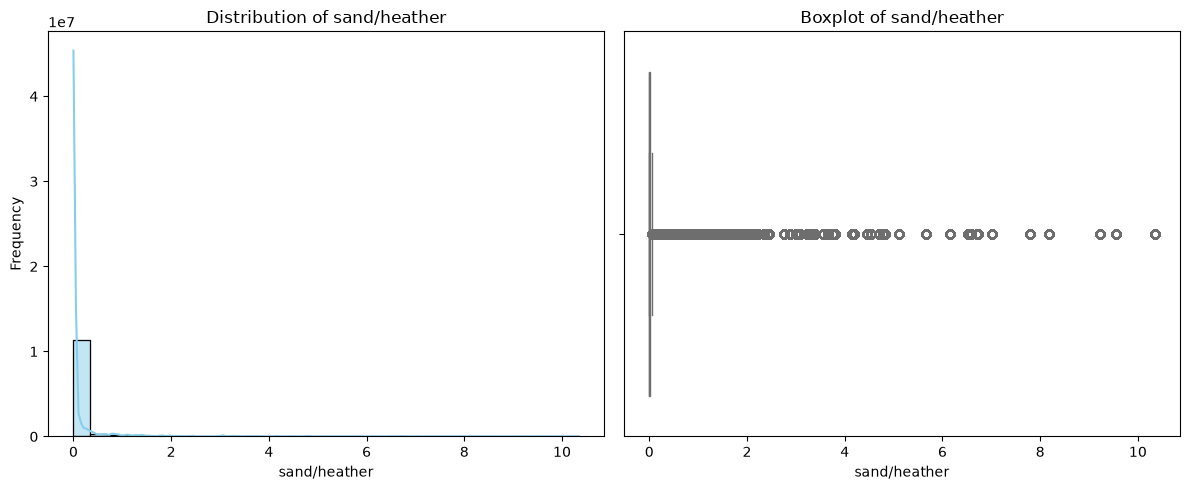


--- sand/heather ---
Mean:     0.188
Median:   0.000
Std:      0.771
Min:      0.000
Max:      10.344
Skewness: 7.121
Missing:  30 rows
--------------------------------------------------


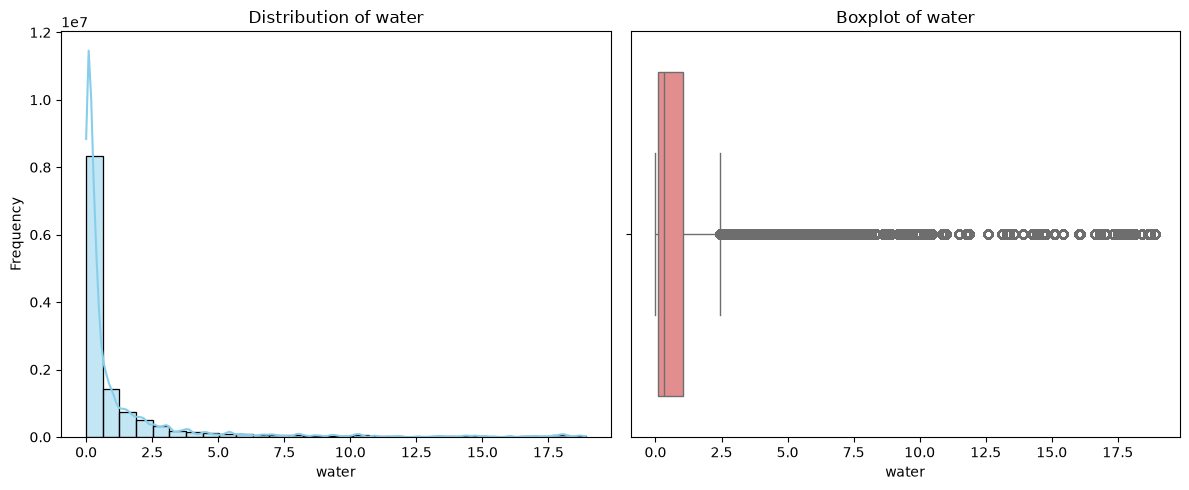


--- water ---
Mean:     1.246
Median:   0.310
Std:      2.688
Min:      0.000
Max:      18.909
Skewness: 4.065
Missing:  30 rows
--------------------------------------------------


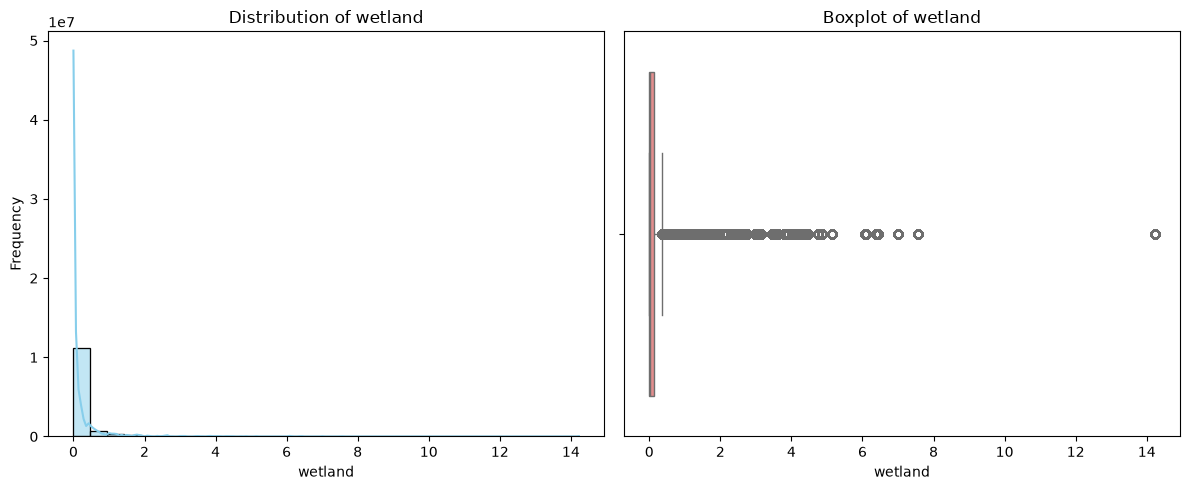


--- wetland ---
Mean:     0.225
Median:   0.018
Std:      0.706
Min:      0.000
Max:      14.224
Skewness: 8.013
Missing:  30 rows
--------------------------------------------------


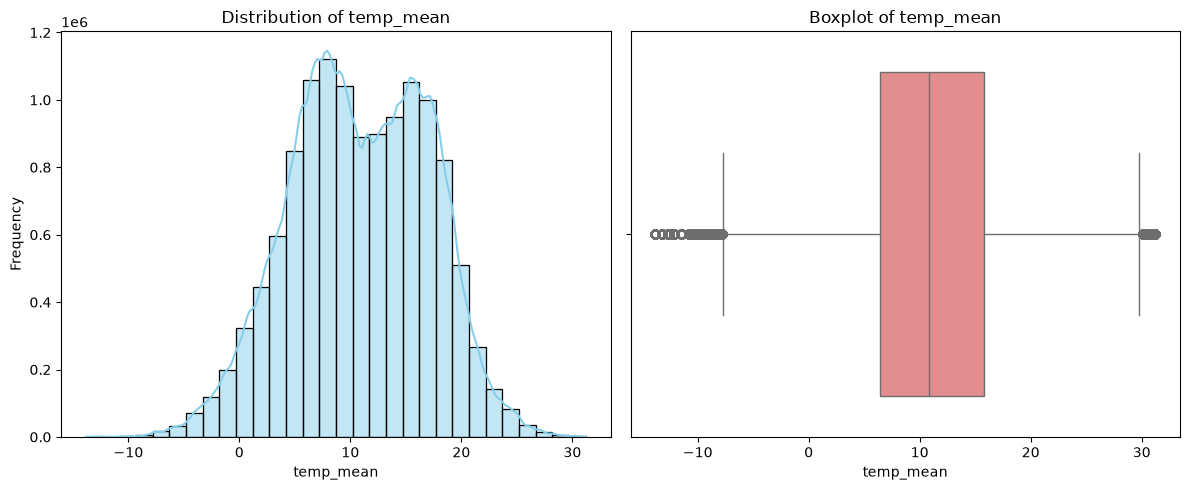


--- temp_mean ---
Mean:     10.870
Median:   10.800
Std:      6.226
Min:      -13.800
Max:      31.200
Skewness: -0.111
Missing:  378 rows
--------------------------------------------------


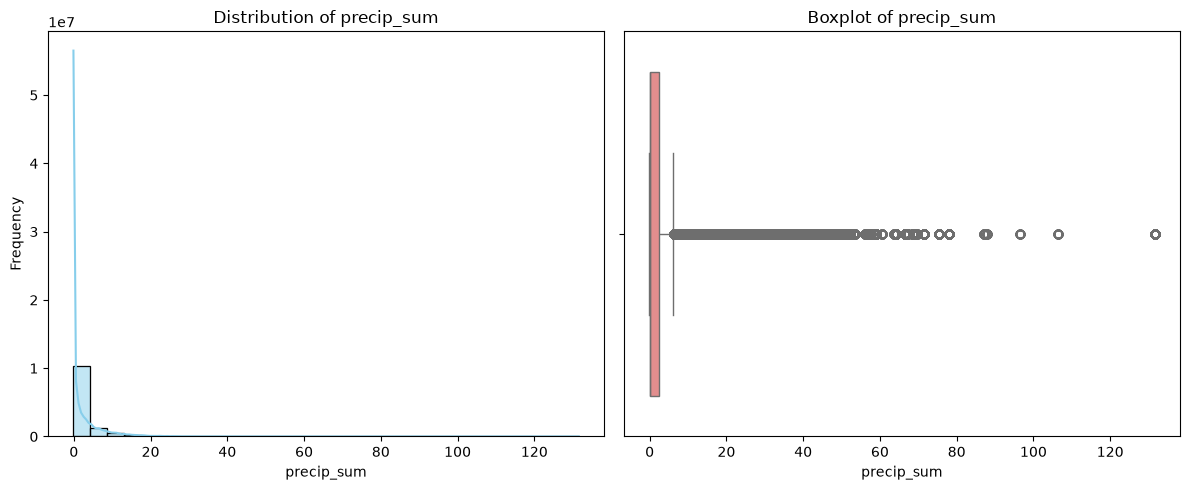


--- precip_sum ---
Mean:     2.255
Median:   0.100
Std:      4.693
Min:      -0.100
Max:      131.600
Skewness: 4.408
Missing:  378 rows
--------------------------------------------------


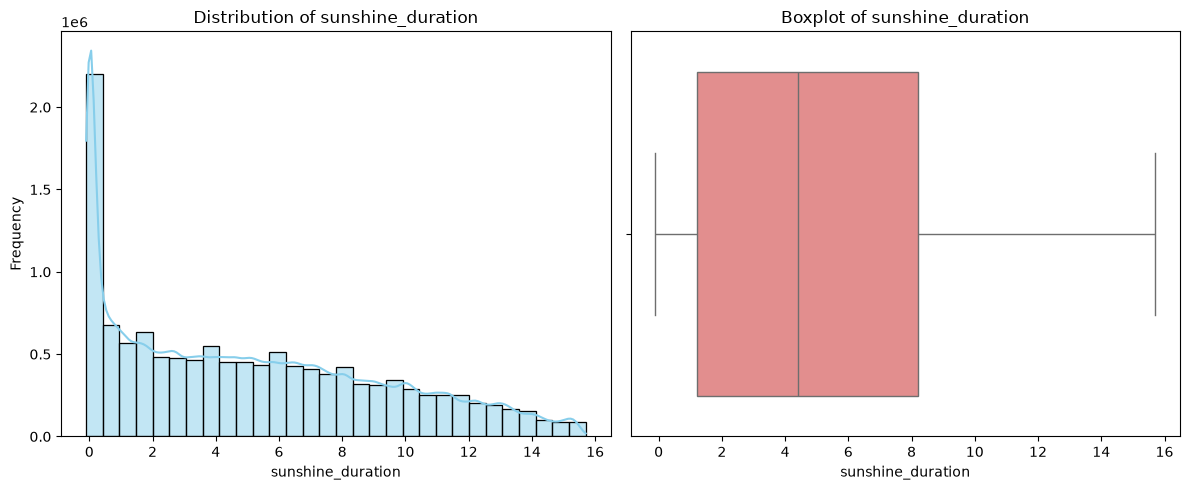


--- sunshine_duration ---
Mean:     5.072
Median:   4.400
Std:      4.236
Min:      -0.100
Max:      15.700
Skewness: 0.541
Missing:  547 rows
--------------------------------------------------


In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

exclude_cols = ['decimalLatitude', 'decimalLongitude', 'day_of_year', 
                'day_sin', 'day_cos']

important_vars = [
    'total_observations', 
    'Oryctolagus cuniculus',
    'agricultural', 'built', 'coast', 'forest', 'other', 
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration'
]

# Filter to only existing important numeric columns
plot_vars = [col for col in important_vars if col in numeric_cols]

print(f"Generating clean plots for {len(plot_vars)} variables...\n")

for col in plot_vars:
    data = df[col].dropna()
    
    data = pd.to_numeric(data, errors='coerce').dropna()
    
    if len(data) == 0:
        print(f"Skipping {col} - no numeric data")
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram with KDE
    sns.histplot(data, kde=True, ax=axes[0], bins=30, color='skyblue')
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    
    # Horizontal Boxplot
    sns.boxplot(x=data, ax=axes[1], orient="h", color='lightcoral')
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n--- {col} ---")
    print(f"Mean:     {data.mean():.3f}")
    print(f"Median:   {data.median():.3f}")
    print(f"Std:      {data.std():.3f}")
    print(f"Min:      {data.min():.3f}")
    print(f"Max:      {data.max():.3f}")
    print(f"Skewness: {data.skew():.3f}")
    print(f"Missing:  {df[col].isna().sum():,} rows")
    print("-" * 50)

The variables show clear patterns typical of ecological data: total_observations is extremely right-skewed due to varying observer effort. Habitat proportions are zero-inflated, especially for natural types (forest, wetland, sand/heather), highlighting sampling bias toward agricultural areas. Weather variables exhibit expected seasonal behavior, with precipitation showing occasional extreme values.


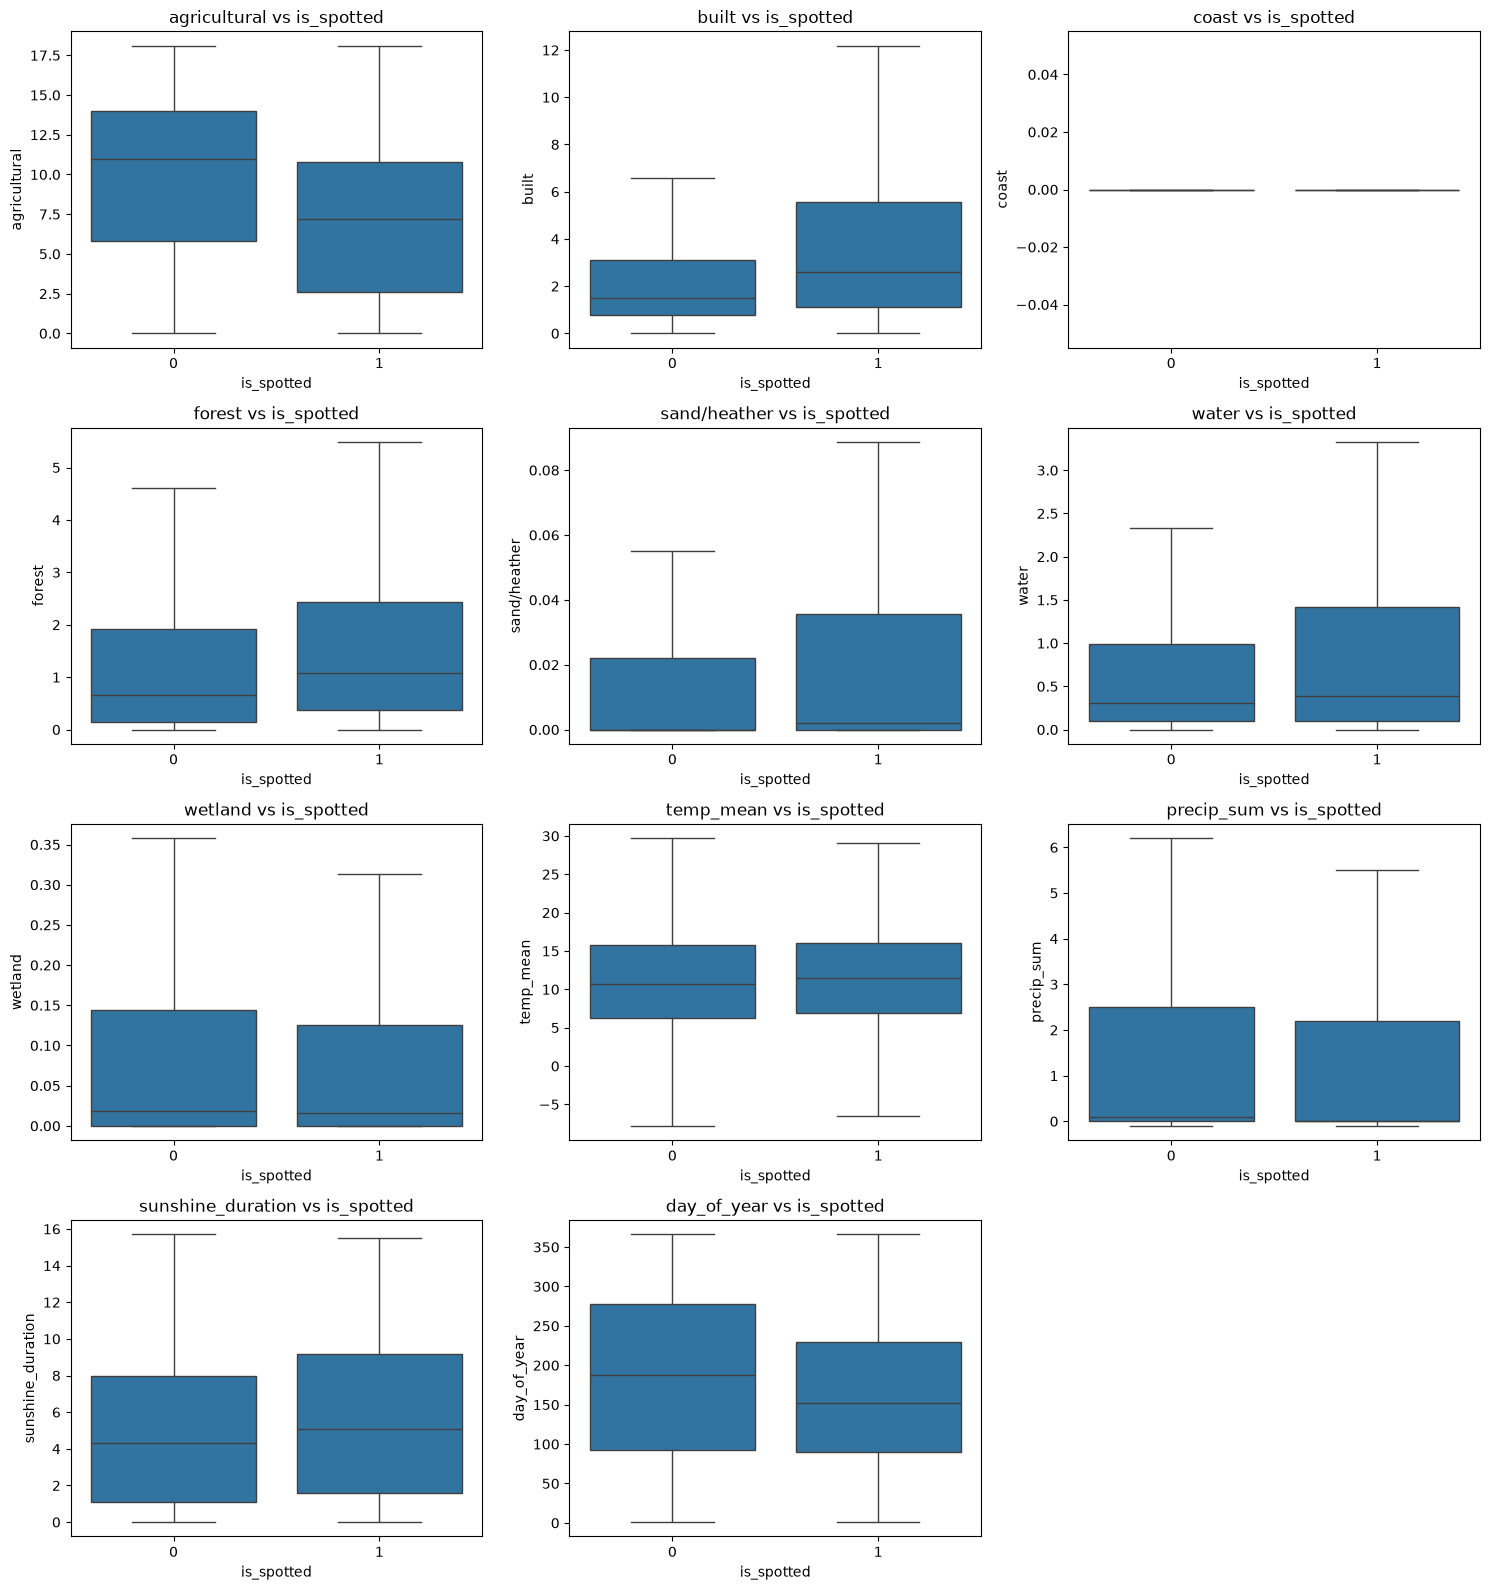

In [11]:
features = [
    'agricultural', 'built', 'coast', 'forest',
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration',
    'day_of_year'
]

target = 'is_spotted'

df_plot = df[[target] + features].copy()

df_plot = df_plot.replace("unknown", pd.NA)
df_plot = df_plot.apply(pd.to_numeric, errors='coerce')

df_plot = df_plot.dropna()

# Sample for speed
df_plot = df_plot.sample(50000, random_state=42)

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(features, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        x=target,
        y=col,
        data=df_plot,
        showfliers=False
    )

    plt.title(f"{col} vs is_spotted")

plt.tight_layout()
plt.show()

**Findings**

Strong predictors of spotting:

Coast: Spottings occur much more often in coastal areas. This is the strongest difference between the two groups.
Agricultural land: Spottings are less common in highly agricultural areas.
Built-up areas: Spottings are more common in built-up or urban areas.
Day of year: Spottings tend to occur earlier in the year.

Variables with smaller effects:

Forest: Slightly higher values are associated with spottings.
Sand/Heather: Slightly more common where these land types are present.
Water: Areas with more water show a small increase in spottings.
Sunshine duration: Spottings are associated with slightly longer sunshine duration, although the difference is small.

Overall: Coastal location, lower agricultural land cover, higher built-up area coverage, and seasonality (earlier in the year) appear to be the most important factors associated with spotting events.

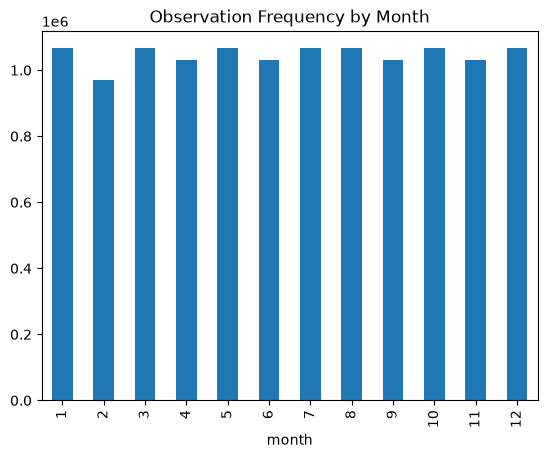

In [12]:
df["eventDate"] = pd.to_datetime(df["eventDate"])

df["month"] = df["eventDate"].dt.month

df["month"].value_counts().sort_index().plot(kind="bar")

plt.title("Observation Frequency by Month")
plt.show()

**Findings**

I wanted to see if there was any seasonal pattern.
Because Bunnies have seasonal behaviors, for example bunny season is from march to september (its the breeding season for the bunnies).

Yet as you can see from the graph our data there is barely any monthly data change which is suprising.

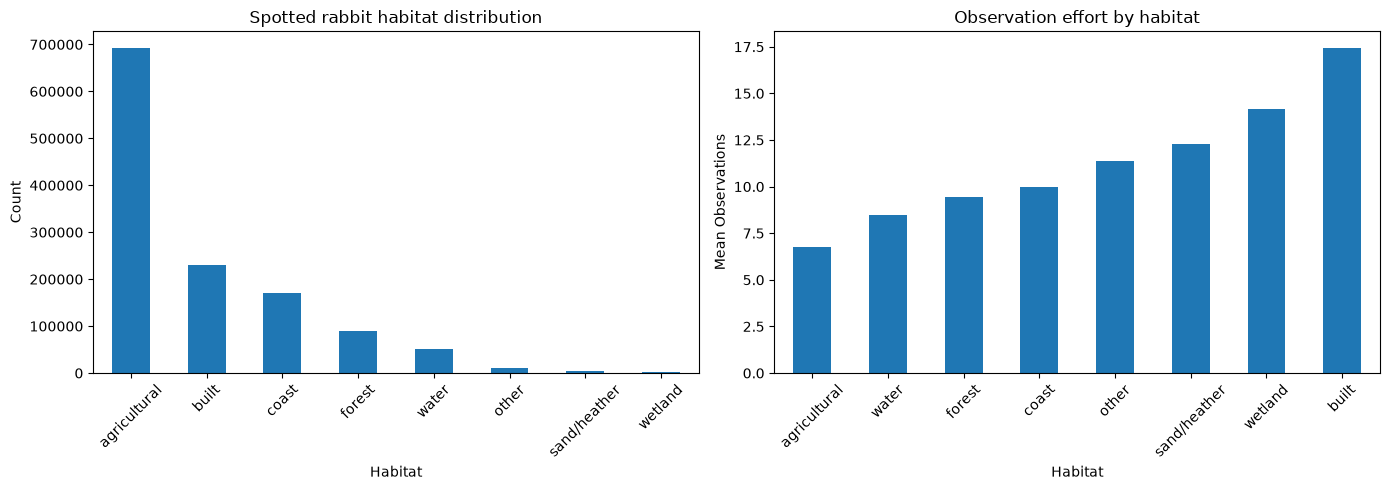

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Spotted rabbit habitat distribution
df[df["is_spotted"] == 1]["main_habitat"] \
    .value_counts() \
    .plot(kind="bar", ax=axes[0])

axes[0].set_title("Spotted rabbit habitat distribution")
axes[0].set_xlabel("Habitat")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)


# 2. Observation effort by habitat
df.groupby("main_habitat")["total_observations"] \
    .mean() \
    .sort_values() \
    .plot(kind="bar", ax=axes[1])

axes[1].set_title("Observation effort by habitat")
axes[1].set_xlabel("Habitat")
axes[1].set_ylabel("Mean Observations")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# filter spotted rabbits
hab = df[df["is_spotted"] == 1]["main_habitat"]

# counts
counts = hab.value_counts(dropna=False)

# percentages
percentages = hab.value_counts(normalize=True, dropna=False) * 100

# combine into one dataframe
result = pd.DataFrame({
    "count": counts,
    "percentage": percentages.round(2)
})

print(result)

               count  percentage
main_habitat                    
agricultural  693252       55.37
built         229902       18.36
coast         169660       13.55
forest         90202        7.20
water          51909        4.15
other           9760        0.78
sand/heather    4366        0.35
wetland         3071        0.25


**Findings**

Most rabbit sightings occur in agricultural areas (53.18%), followed by built areas (19.04%) and coastal areas (15.61%).

Built areas have the highest observation effort, while agricultural areas have the lowest observation effort.

Despite the lower observation effort, agricultural areas have the most rabbit sightings, suggesting that rabbits are genuinely more common in these habitats rather than being observed more often because of increased surveying.

The relatively high number of sightings in built areas may be partly explained by the greater observation effort and easier access for observers.

Sand/heather and wetland habitats have few sightings and relatively low observation effort, so it is difficult to draw strong conclusions about rabbit presence in these environments.


**Rabbit spots related to habitat**

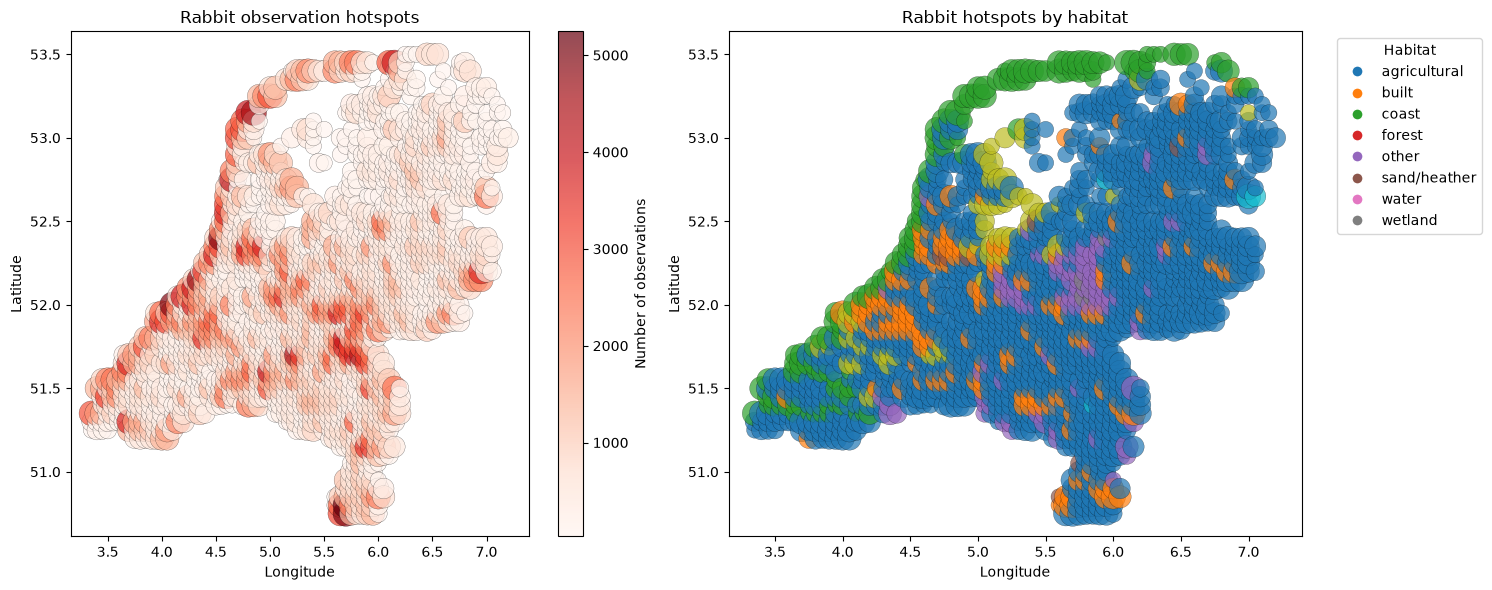

In [15]:
df_spotted = df[df["is_spotted"] == 1]

# 1. Location-only hotspot map
loc_counts_1 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude"]
).size().reset_index(name="count")

loc_counts_1["log_count"] = np.log1p(loc_counts_1["count"])

# 2. Location + habitat map
loc_counts_2 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude", "main_habitat"]
).size().reset_index(name="count")

loc_counts_2["log_count"] = np.log1p(loc_counts_2["count"])

habitats = loc_counts_2["main_habitat"].astype("category")
colors = habitats.cat.codes

# 3. Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(
    loc_counts_1["decimalLongitude"],
    loc_counts_1["decimalLatitude"],
    s=loc_counts_1["log_count"] * 40,
    c=loc_counts_1["count"],
    cmap="Reds",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[0].set_title("Rabbit observation hotspots")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("Number of observations")

sc2 = axes[1].scatter(
    loc_counts_2["decimalLongitude"],
    loc_counts_2["decimalLatitude"],
    s=loc_counts_2["log_count"] * 40,
    c=colors,
    cmap="tab10",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[1].set_title("Rabbit hotspots by habitat")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# habitat legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cm.tab10(i),
               markersize=8,
               label=cat)
    for i, cat in enumerate(habitats.cat.categories)
]

axes[1].legend(handles=handles, title="Habitat",
               bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Findings**

Most of the rabbit observations are concentrated in specific geographic hotspots, showing a clear uneven spatial distribution of the data. This indicates that the dataset is not uniformly sampled across the study area.

The observation effort map shows that data collection is higher in agricultural and built environments, suggesting a potential sampling bias toward more accessible or frequently surveyed areas.

As a result, the observed habitat distribution of rabbits is likely influenced by where observations are made rather than only true habitat preference. Natural habitats such as forests, wetlands, and sand/heather are less represented, so conclusions about these areas are less reliable.

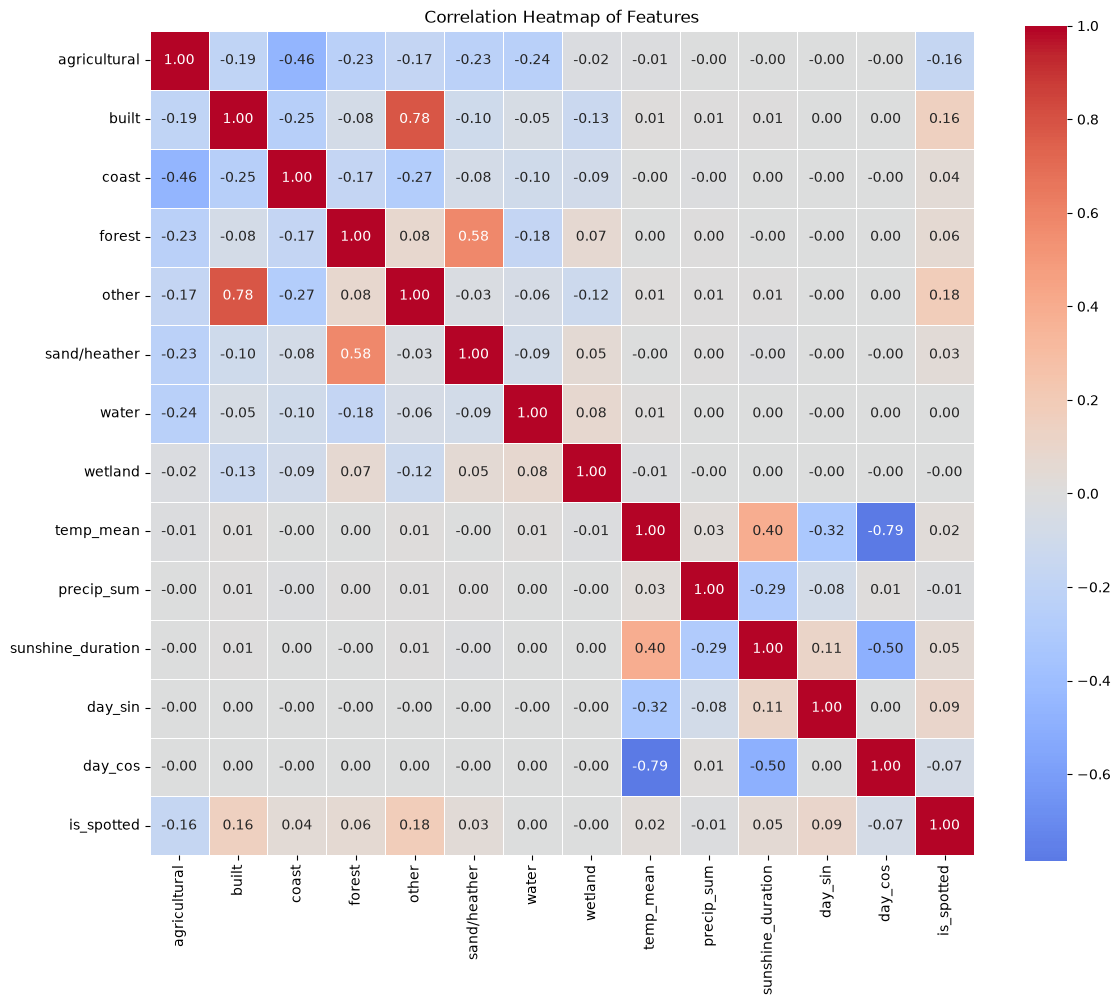

In [16]:
features = [
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_sin",
    "day_cos",
    "is_spotted"
]

# Calculate correlation matrix
corr_matrix = df[features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

**Findings**

Because all values in the is_spotted row are extremely close to zero, it can be concluded that there is no single linear feature that strongly predicts whether something is spotted. This suggests that the relationship between these features and is_spotted is likely non-linear or complex, and cannot be captured through simple correlation analysis.

## Overall Findings of Data Understanding


# 2.2 Data preparation

**Check duplicates, missing values or typos**

In [17]:
df.isnull().sum()

decimalLatitude                0
decimalLongitude               0
eventDate                      0
total_observations             3
speciesgroup_observations      0
Oryctolagus cuniculus          0
agricultural                  30
built                         30
coast                         30
forest                        30
other                         30
sand/heather                  30
water                         30
wetland                       30
main_habitat                  30
nearest_station                0
station_name                   0
temp_mean                    378
precip_sum                   378
sunshine_duration            547
spotted                        0
is_spotted                     0
day_of_year                    0
day_sin                        0
day_cos                        0
month                          0
dtype: int64

In [18]:
df["total_observations"] = df["total_observations"].fillna(df["total_observations"].median())
df = df.dropna()
#check for missing values
df.isnull().sum()   

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Oryctolagus cuniculus        0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
nearest_station              0
station_name                 0
temp_mean                    0
precip_sum                   0
sunshine_duration            0
spotted                      0
is_spotted                   0
day_of_year                  0
day_sin                      0
day_cos                      0
month                        0
dtype: int64

* *We removed all the zero values because when we took a closer look all the values were extreme and not similar at all to the rest of the data*

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
print(habitat["main_habitat"].unique())

<StringArray>
['agricultural',        'built',        'other',        'water',
       'forest',        'coast', 'sand/heather',      'wetland',
         'dirt']
Length: 9, dtype: str


In [21]:
scaler = StandardScaler()

df[["temp_mean", "precip_sum", "sunshine_duration"]] = scaler.fit_transform(
    df[["temp_mean", "precip_sum", "sunshine_duration"]]
)

This code applies standard scaling to the KNMI weather variables (temp_mean, precip_sum, and sunshine_duration).

It transforms these features so they all have a mean of 0 and a standard deviation of 1. This ensures that variables with different units and ranges (°C, mm, hours) become comparable and no single variable dominates the analysis due to its scale.

It was implemented as a preprocessing step to improve data consistency across environmental features and to prepare the dataset for analysis or modelling where feature magnitude can influence results.

# 3. Modeling
**Model Validation Strategy**

In [22]:
# target
target = "is_spotted"


# features
features = [
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_sin",
    "day_cos"
]


df_model = df[features + [target]].copy()

df_model = df_model.apply(pd.to_numeric, errors="coerce")
df_model = df_model.dropna()

X = df_model[features]
y = df_model[target]

# stratified Kfold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print(f"\nFOLD {fold + 1}")

    print("Train size:", len(X_train))
    print("Test size:", len(X_test))

    print("\nTrain class balance:")
    print(y_train.value_counts(normalize=True))

    print("\nTest class balance:")
    print(y_test.value_counts(normalize=True))

    print("-" * 40)


FOLD 1
Train size: 10046524
Test size: 2511631

Train class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64
----------------------------------------

FOLD 2
Train size: 10046524
Test size: 2511631

Train class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64
----------------------------------------

FOLD 3
Train size: 10046524
Test size: 2511631

Train class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.900299
1    0.099701
Name: proportion, dtype: float64
----------------------------------------

FOLD 4
Train size: 10046524
Test size: 2511631

Train class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.900299
1    0.0

We train test splitted the data into 80% training and 20% testing sets, while maintaining the same proportion of rabbit observations (is_spotted) in both sets.

Model

In [23]:
model1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.6684827508499457
              precision    recall  f1-score   support

           0       0.96      0.66      0.78   2261220
           1       0.19      0.72      0.30    250411

    accuracy                           0.67   2511631
   macro avg       0.57      0.69      0.54   2511631
weighted avg       0.88      0.67      0.73   2511631

Recall: 0.7204395973020354

Confusion Matrix:
[[1498576  762644]
 [  70005  180406]]


In [24]:
model2 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y[y==0]) / len(y[y==1]),
    random_state=42,
    eval_metric='logloss'
)

# Train
model2.fit(X_train, y_train)

# Predict
y_pred = model2.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1740253  520967]
 [  49311  201100]]
              precision    recall  f1-score   support

           0       0.97      0.77      0.86   2261220
           1       0.28      0.80      0.41    250411

    accuracy                           0.77   2511631
   macro avg       0.63      0.79      0.64   2511631
weighted avg       0.90      0.77      0.81   2511631



In [25]:
# 1. Calculate the class imbalance ratio dynamically
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Instantiate the base model
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Define the hyperparameter space to search
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [ratio]
}

# 4. Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 5. Run the hyperparameter search
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# 6. Extract the best model and parameters
best_model = random_search.best_estimator_
print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best CV F1-Score: {random_search.best_score_:.4f}\n")

# 7. Predict and Evaluate using the tuned model
y_pred_tuned = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Starting hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 